In [6]:
dataset['Data_zamowienia'] = pd.to_datetime(dataset['Data_zamowienia'], format='%m/%d/%Y %H:%M')

dataset['Dzien_tygodnia_zamowienia'] = dataset['Data_zamowienia'].dt.dayofweek  # 0=poniedziałek
dataset['Miesiac_zamowienia'] = dataset['Data_zamowienia'].dt.month

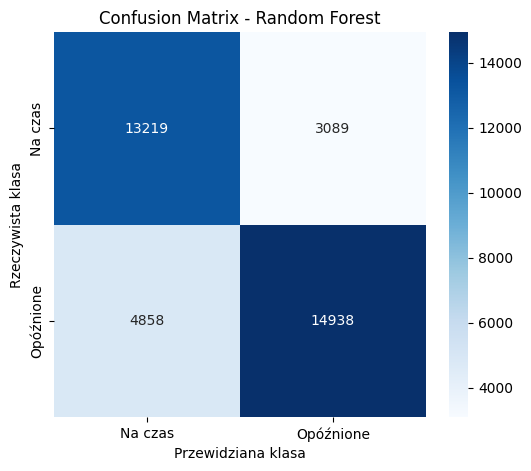

<Figure size 700x600 with 0 Axes>

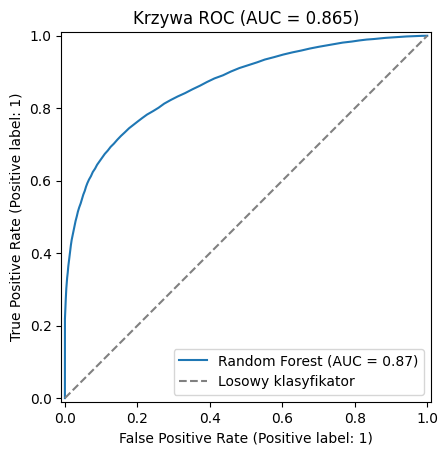

AUC Score: 0.8651


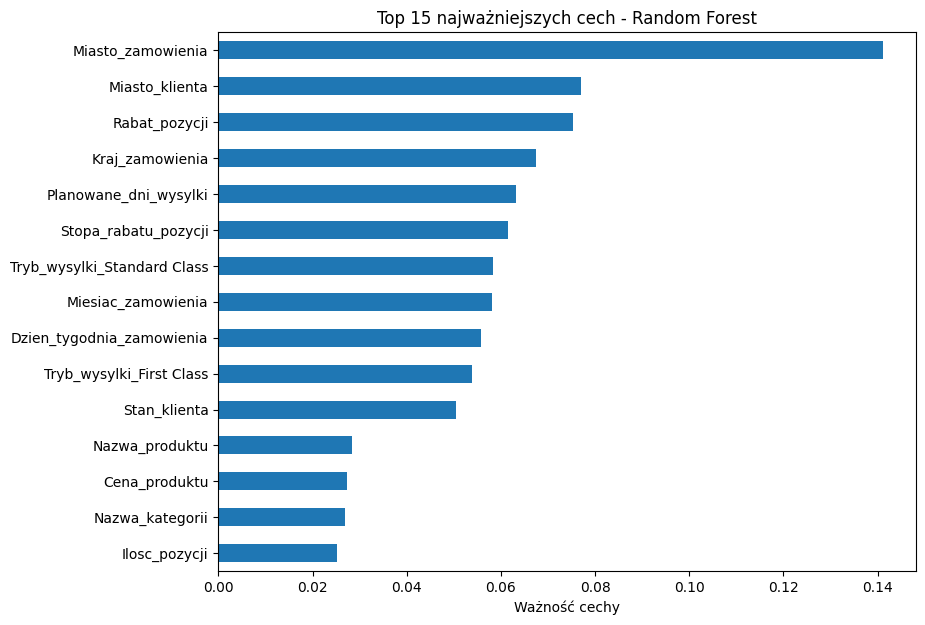

Miasto_zamowienia              0.141059
Miasto_klienta                 0.077031
Rabat_pozycji                  0.075326
Kraj_zamowienia                0.067479
Planowane_dni_wysylki          0.063144
Stopa_rabatu_pozycji           0.061527
Tryb_wysylki_Standard Class    0.058228
Miesiac_zamowienia             0.058193
Dzien_tygodnia_zamowienia      0.055671
Tryb_wysylki_First Class       0.053846
Stan_klienta                   0.050546
Nazwa_produktu                 0.028445
Cena_produktu                  0.027364
Nazwa_kategorii                0.026998
Ilosc_pozycji                  0.025114
dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, RocCurveDisplay, roc_auc_score
import os

os.makedirs('wykresy', exist_ok=True)

rf_model = modele["Random Forest"]  

# 1. Confusion Matrix
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Na czas', 'Opóźnione'],
            yticklabels=['Na czas', 'Opóźnione'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Rzeczywista klasa')
plt.xlabel('Przewidziana klasa')
plt.savefig('wykresy/07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Krzywa ROC z AUC
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(7,6))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Losowy klasyfikator')
plt.title(f'Krzywa ROC (AUC = {auc_score:.3f})')
plt.legend()
plt.savefig('wykresy/08_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC Score: {auc_score:.4f}")

# 3. Feature importance (Top 15)
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9,7))
top15.plot(kind='barh')
plt.title('Top 15 najważniejszych cech - Random Forest')
plt.xlabel('Ważność cechy')
plt.gca().invert_yaxis()
plt.savefig('wykresy/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(top15)